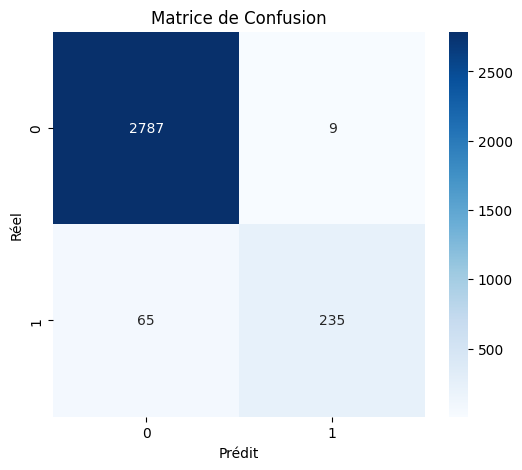

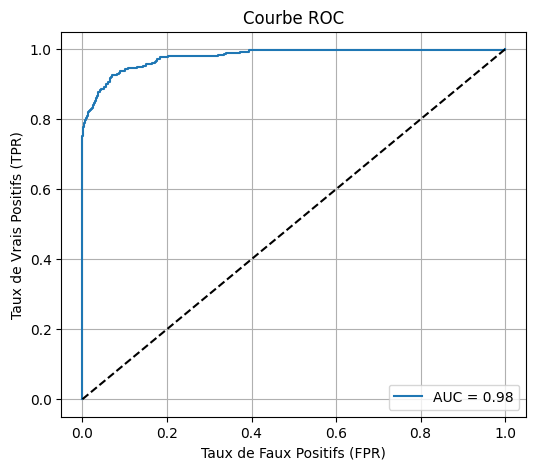

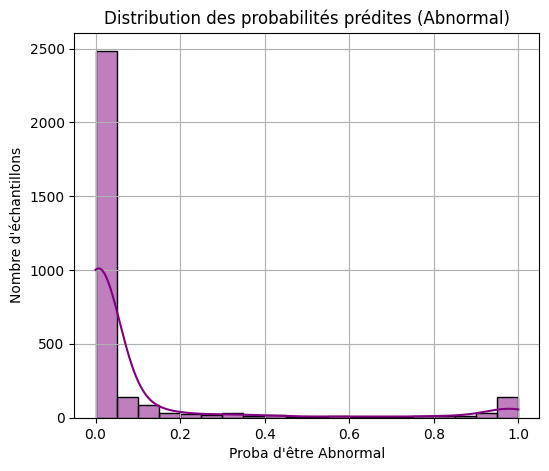

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

# Charger le dataset
df = pd.read_csv('/content/5_with_soft_probabilities.csv')

# Préparation des données
X = df.drop(columns=['Status', 'Proba_Normal (%)', 'Unnamed: 0'], errors='ignore')
y = df['Status'].map({'Normal': 0, 'Abnormal': 1})  # Binaire

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Proba pour classe "Abnormal" (1)

# === 1. Matrice de confusion ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# === 2. Courbe ROC ===
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

# === 3. Histogramme des probabilités ===
plt.figure(figsize=(6, 5))
sns.histplot(y_prob, bins=20, kde=True, color='purple')
plt.title("Distribution des probabilités prédites (Abnormal)")
plt.xlabel("Proba d'être Abnormal")
plt.ylabel("Nombre d'échantillons")
plt.grid(True)
plt.show()


In [ ]:
!python --version


Python 3.11.13


In [ ]:
import joblib

# Sauvegarder le modèle et le scaler
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime
from threading import Thread, Event
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import ipywidgets as widgets
import joblib

# --- Configuration ---
USERNAME = "****"
PASSWORD = "****"
CSV_PATH = "historique_predictions.csv"

stop_flag = Event()
historique = pd.DataFrame()

# === Chargement du modèle et du scaler ===
def load_model():
    model = joblib.load('/content/model nv.pkl')
    scaler = joblib.load('/content/scaler nv.pkl')
    return model, scaler

# === Authentification & données API ===
def get_token():
    url = "https://iot1.bigherdsman.com/api/v2/account/login/"
    creds = {"username": USERNAME, "password": PASSWORD}
    resp = requests.post(url, json=creds)
    return resp.json()["data"]["token"]

def get_farm_code(headers):
    url = "https://iot1.bigherdsman.com/api/v2/entity/farm"
    resp = requests.get(url, headers=headers)
    return resp.json()["data"][0]["code"]

def get_humidite_critique(age):
    table_critique = {
        1: 70, 2: 70, 3: 70, 4: 70, 5: 70, 6: 70, 7: 65, 8: 65, 9: 65, 10: 65,
        11: 65, 12: 65, 13: 65, 14: 60, 15: 60, 16: 60, 17: 60, 18: 60,
        19: 60, 20: 60, 21: 55, 22: 55, 23: 55, 24: 55, 25: 55, 26: 55,
        27: 50, 28: 50, 29: 50, 30: 50, 31: 50, 32: 50, 33: 50, 34: 50,
        35: 50, 36: 50, 37: 50, 38: 50, 39: 50, 40: 50, 41: 50, 42: 50,
        43: 50, 44: 50, 45: 50, 47: 50, 48: 50
    }
    return table_critique.get(int(age), 50)

# === Analyse des données ===
def fetch_and_predict_once(model, scaler):
    global historique
    try:
        token = get_token()
        headers = {"Authorization": f"Token {token}"}
        farm_code = get_farm_code(headers)

        url = f"https://iot1.bigherdsman.com/api/v2/current/list/?code={farm_code}"
        resp = requests.get(url, headers=headers)
        data = resp.json()["data"]

        df = pd.DataFrame(data)
        df_flat = pd.json_normalize(df['data'])
        df = pd.concat([df[['ts']], df_flat], axis=1)
        df['datetime'] = pd.to_datetime(df['ts'].astype(int), unit='s')

        df = df.rename(columns={
            'age': 'Age', 'co2': 'CO2', 't_t': 'Req Temp',
            't_cur': 'Temp', 'h_r': 'Humidity'
        })

        # Convertir les colonnes numériques
        for col in ['Age', 'Humidity', 'CO2', 'Temp', 'Req Temp']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Ajouter humidité critique
        df['Humidite_Critique (%)'] = df['Age'].apply(get_humidite_critique)

        # 🧠 Utiliser uniquement les features connues du modèle
        features = [
            'Age', 'CO2', 'Req Temp', 'Temp', 'Humidity', 'Humidite_Critique (%)'
        ]

        X = df[features]
        X_scaled = scaler.transform(X)

        # Prédiction
        y_proba = model.predict_proba(X_scaled)[:, 1]
        seuil = 0.5
        df['Status'] = np.where(y_proba >= seuil, 'Abnormal', 'Normal')

        df['Proba_Abnormal (%)'] = (y_proba * 100).round(2)
        df['Proba_Normal (%)'] = (100 - y_proba * 100).round(2)

        final_df = df[['datetime'] + features + ['Status', 'Proba_Normal (%)', 'Proba_Abnormal (%)']]

        historique = pd.concat([historique, final_df], ignore_index=True)
        historique.to_csv(CSV_PATH, index=False)

        # ✅ Affichage ligne par ligne
        print(f"\n📥 [{datetime.now()}] Données récupérées ({len(final_df)} ligne(s)) :\n")
        for i, row in final_df.iterrows():
            print(f"🟡 Ligne {i+1}: {row.to_dict()}")

    except Exception as e:
        print(f"[{datetime.now()}] ❌ Erreur :", e)

# === Surveillance temps réel ===
def start_surveillance(model, scaler):
    while not stop_flag.is_set():
        fetch_and_predict_once(model, scaler)
        time.sleep(15)

def run_threaded(model, scaler):
    stop_flag.clear()
    thread = Thread(target=start_surveillance, args=(model, scaler))
    thread.start()

# === Interface utilisateur ===
model, scaler = load_model()
button_start = widgets.Button(description="▶️ Démarrer", button_style='success')
button_stop = widgets.Button(description="⏹️ Arrêter", button_style='danger')

def on_start_clicked(b):
    print("🔄 Surveillance en temps réel démarrée...")
    run_threaded(model, scaler)

def on_stop_clicked(b):
    stop_flag.set()
    print("🛑 Surveillance arrêtée par l'utilisateur.")

button_start.on_click(on_start_clicked)
button_stop.on_click(on_stop_clicked)

display(widgets.HBox([button_start, button_stop]))


🔄 Surveillance en temps réel démarrée...
🛑 Surveillance arrêtée par l'utilisateur.


<ipython-input-2-100b0b1069a7>:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-2-100b0b1069a7>:23: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-2-100b0b1069a7>:23: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-2-100b0b1069a7>:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/cor

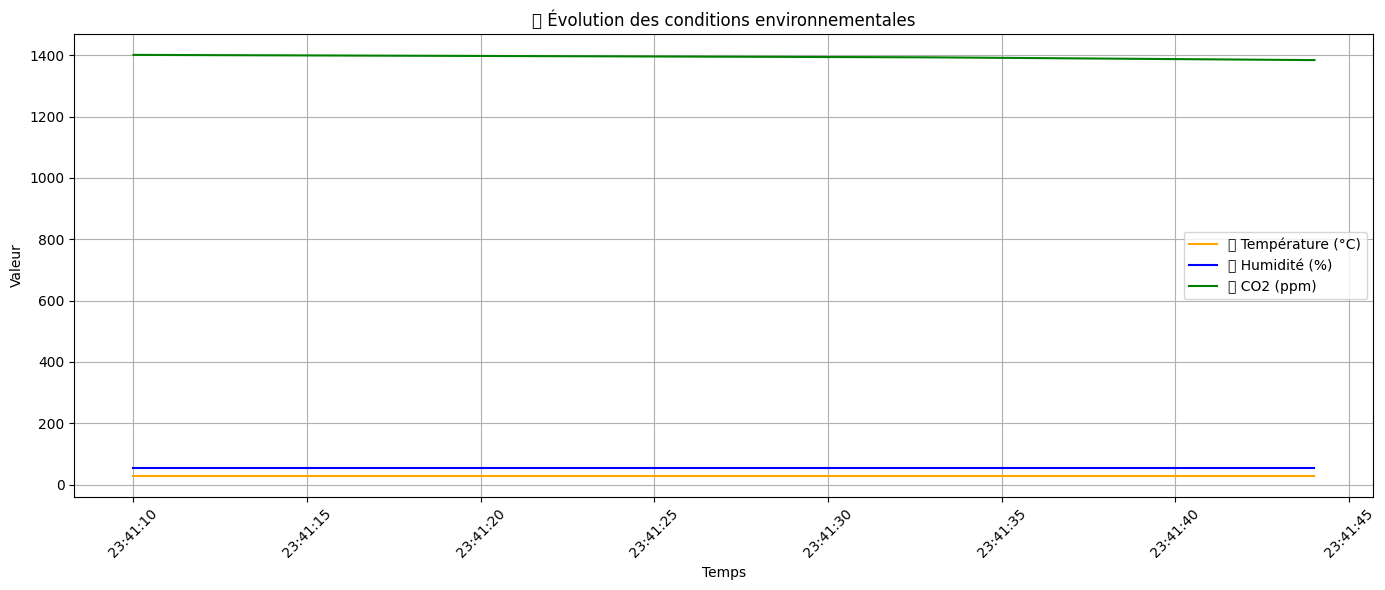

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Charger les données du fichier CSV
df = pd.read_csv("historique_predictions.csv")

# S'assurer que la colonne datetime est bien au format datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Tracer les courbes de Température, Humidité et CO2
plt.figure(figsize=(14, 6))

plt.plot(df['datetime'], df['Temp'], label='🌡️ Température (°C)', color='orange')
plt.plot(df['datetime'], df['Humidity'], label='💧 Humidité (%)', color='blue')
plt.plot(df['datetime'], df['CO2'], label='🟢 CO2 (ppm)', color='green')

plt.title("📈 Évolution des conditions environnementales")
plt.xlabel("Temps")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
